In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_theme(style="darkgrid")



In [5]:
df = pd.read_csv('health_lifestyle_dataset_v2.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1200, 13)

First 5 rows:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,Target
0,83.869438,153.961967,28.458030,2882.204442,2411.309546,42.820749,4.929991,63.068556,8.947404,82.191100,1.965922,8.387041,2
1,73.779276,146.699956,47.124015,6209.856902,2626.209523,52.870960,7.378563,68.516671,6.557501,28.734014,2.673010,5.904811,1
2,64.917832,152.155123,54.079863,9759.299531,2088.006454,95.949949,7.771757,88.326967,8.103200,68.041500,1.467820,5.656736,1
3,NaN,138.101991,57.975496,8773.554310,2557.975557,92.260668,7.972459,95.492068,6.942789,22.430546,3.212594,1.959808,0
4,74.248683,146.749932,60.906615,8399.770373,1478.541325,41.827622,5.246780,69.524471,6.451926,NaN,2.100959,6.747875,1


In [9]:
print("Column names:",df.columns.tolist())

Column names: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'Target']


In [10]:
print("Target distribution:")
print(df['Target'].value_counts())
print("\nTarget percentages:")
print(df['Target'].value_counts(normalize=True) * 100)

Target distribution:
2    400
1    400
0    400
Name: Target, dtype: int64

Target percentages:
2    33.333333
1    33.333333
0    33.333333
Name: Target, dtype: float64


### 1. Preprocessing

In [13]:
# Separate features (X1-X12) and target
X = df.drop('Target', axis=1)
y = df['Target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1200, 12)
Target shape: (1200,)


In [15]:
# Checking missing values 

print("Missing values before handling :")
print(X.isnull().sum())

# Replace missing values with column mean
X_filled = X.copy()
for col in X_filled.columns:
    if X_filled[col].isnull().any():
        col_mean = X_filled[col].mean()
        X_filled[col].fillna(col_mean, inplace=True)
        print(f"Filled {X[col].isnull().sum()} missing values in {col}")

print("\nMissing values after handling:", X_filled.isnull().sum().sum())

Missing values before handling :
X1     51
X2     75
X3     69
X4     54
X5     56
X6     56
X7     58
X8     49
X9     71
X10    67
X11    60
X12    61
dtype: int64
Filled 51 missing values in X1
Filled 75 missing values in X2
Filled 69 missing values in X3
Filled 54 missing values in X4
Filled 56 missing values in X5
Filled 56 missing values in X6
Filled 58 missing values in X7
Filled 49 missing values in X8
Filled 71 missing values in X9
Filled 67 missing values in X10
Filled 60 missing values in X11
Filled 61 missing values in X12

Missing values after handling: 0


In [17]:
# Standardize features using StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

X_scaled_df = pd.DataFrame(X_scaled, columns=X_filled.columns)

print("Scaled data mean:", X_scaled_df.mean().mean())
print("Scaled data std:", X_scaled_df.std().mean())

Scaled data mean: 1.070931537894282e-16
Scaled data std: 1.00041692726431


### 2. Dimensionality Reduction (PCA)

In [18]:
# Applying PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y.values

print(f"Explained variance ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Explained variance ratio:
PC1: 56.50%
PC2: 6.12%
Total: 62.62%


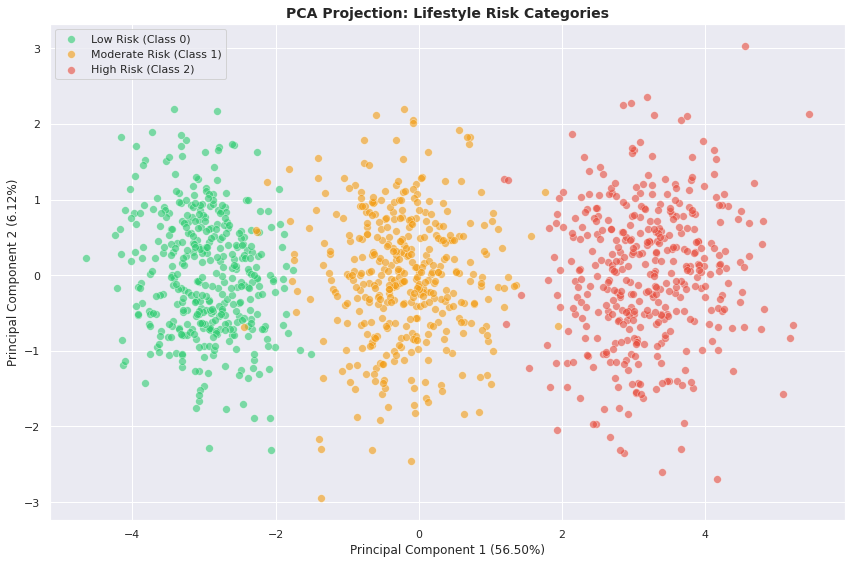

In [19]:
# Visualizing PCA projection with classes

plt.figure(figsize=(12, 8))

colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
labels = {0: 'Low Risk (Class 0)', 1: 'Moderate Risk (Class 1)', 2: 'High Risk (Class 2)'}

for target_class in [0, 1, 2]:
    mask = pca_df['Target'] == target_class
    plt.scatter(pca_df.loc[mask, 'PC1'], 
                pca_df.loc[mask, 'PC2'],
                c=colors[target_class], 
                label=labels[target_class],
                alpha=0.6, 
                edgecolors='white',
                linewidth=0.5,
                s=60)

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('PCA Projection: Lifestyle Risk Categories', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 3.  Modelling 

In [20]:
# Splitting the PCA-transformed data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 960 samples
Test set size: 240 samples


In [21]:
# Training Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

print(f"Tree depth: {dt_classifier.get_depth()}")
print(f"Number of leaves: {dt_classifier.get_n_leaves()}")

Tree depth: 7
Number of leaves: 17


### 4. Evaluation

In [22]:
# Prediction on training and test sets
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

# Calculating accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nAccuracy difference: {train_accuracy - test_accuracy:.4f}")

MODEL PERFORMANCE METRICS

Training Accuracy: 1.0000 (100.00%)
Test Accuracy: 0.9750 (97.50%)

Accuracy difference: 0.0250


Training Set Confusion Matrix:


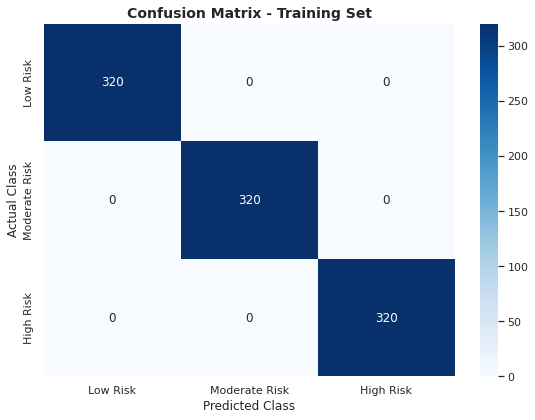


Test Set Confusion Matrix:


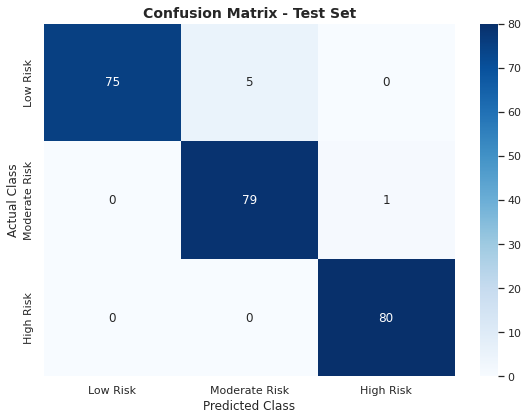

In [24]:
# Function to plot confusion matrix

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low Risk', 'Moderate Risk', 'High Risk'],
                yticklabels=['Low Risk', 'Moderate Risk', 'High Risk'])
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('Actual Class', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return cm

# Plotting training confusion matrix
print("Training Set Confusion Matrix:")
train_cm = plot_confusion_matrix(y_train, y_train_pred, 'Confusion Matrix - Training Set')

# Plotting test confusion matrix
print("\nTest Set Confusion Matrix:")
test_cm = plot_confusion_matrix(y_test, y_test_pred, 'Confusion Matrix - Test Set')

In [25]:
# Detailed classification report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 50)
print(classification_report(y_test, y_test_pred, 
                          target_names=['Low Risk (0)', 'Moderate Risk (1)', 'High Risk (2)']))


CLASSIFICATION REPORT - TEST SET
                   precision    recall  f1-score   support

     Low Risk (0)       1.00      0.94      0.97        80
Moderate Risk (1)       0.94      0.99      0.96        80
    High Risk (2)       0.99      1.00      0.99        80

         accuracy                           0.97       240
        macro avg       0.98      0.97      0.97       240
     weighted avg       0.98      0.97      0.97       240



### 5. Decision Tree Visualization

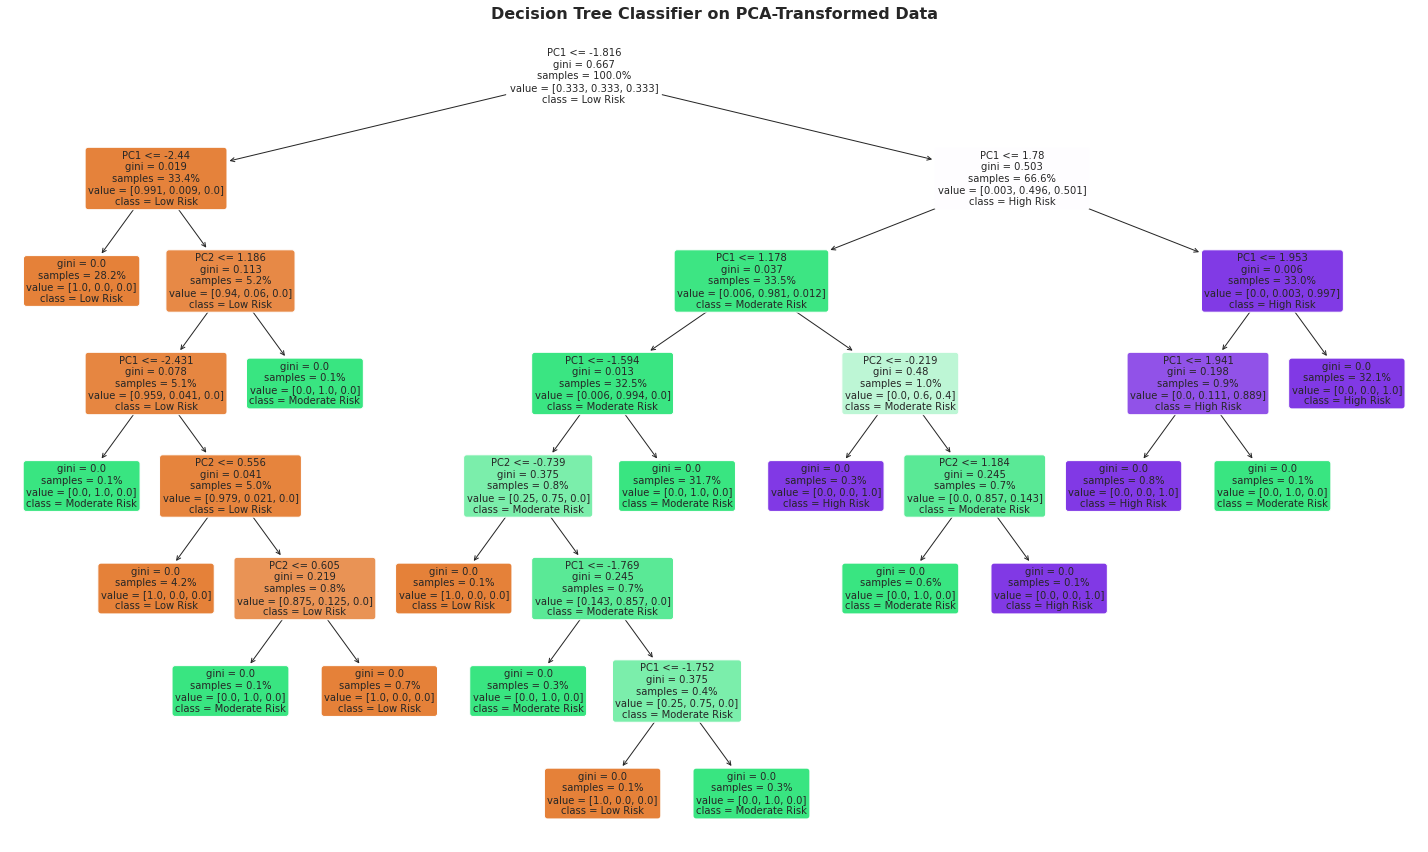

In [26]:
# Visualizing the decision tree

plt.figure(figsize=(20, 12))
plot_tree(dt_classifier, 
          feature_names=['PC1', 'PC2'],
          class_names=['Low Risk', 'Moderate Risk', 'High Risk'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title('Decision Tree Classifier on PCA-Transformed Data', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Additional Visualizations

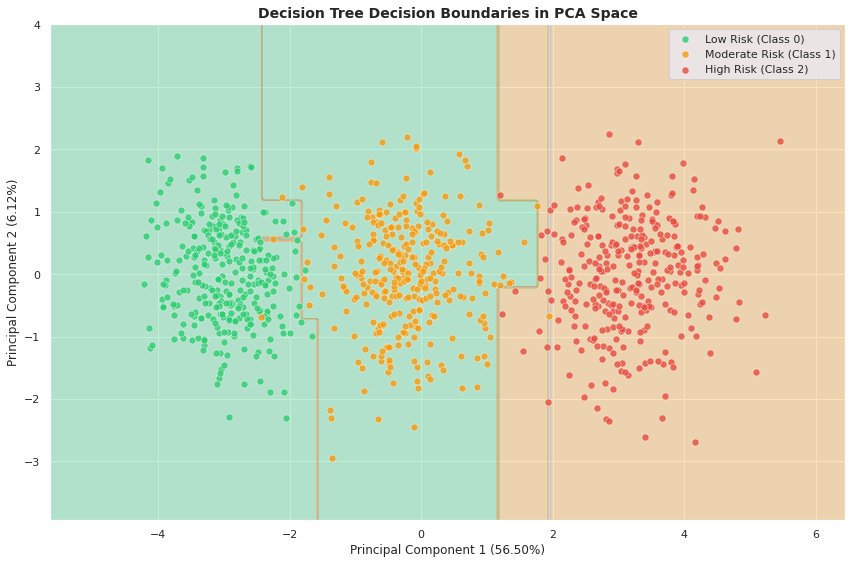

In [27]:
# Creating mesh grid for decision boundary visualization
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Prediction on mesh grid
Z = dt_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.3, colors=['#2ecc71', '#f39c12', '#e74c3c'])

for target_class in [0, 1, 2]:
    mask = y_train == target_class
    plt.scatter(X_train[mask, 0], X_train[mask, 1],
                c=colors[target_class], 
                label=labels[target_class],
                edgecolors='white',
                linewidth=0.5,
                s=50,
                alpha=0.8)

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('Decision Tree Decision Boundaries in PCA Space', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 6. Summary and Interpretation

In [29]:
print("=" * 70)
print("PROJECT SUMMARY: Smart Health Monitoring")
print("=" * 70)

print("\n📊 DATASET OVERVIEW")
print("-" * 50)
print(f"• Total samples: {len(df)}")
print(f"• Features: 12 (X1-X12)")
print(f"• Target classes: 3 (0=Low Risk, 1=Moderate Risk, 2=High Risk)")

print("\n🔧 PREPROCESSING STEPS")
print("-" * 50)
print("• Missing values handled using column means")
print("• Features standardized using StandardScaler")

print("\n📉 PCA RESULTS")
print("-" * 50)
print(f"• Reduced from 12 dimensions to 2 components")
print(f"• PC1 explains: {pca.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"• PC2 explains: {pca.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"• Total variance preserved: {sum(pca.explained_variance_ratio_)*100:.2f}%")

print("\n🤖 MODEL PERFORMANCE")
print("-" * 50)
print(f"• Algorithm: Decision Tree Classifier")
print(f"• Training accuracy: {train_accuracy*100:.2f}%")
print(f"• Test accuracy: {test_accuracy*100:.2f}%")

print("\n💡 INTERPRETATION")
print("-" * 50)
if train_accuracy - test_accuracy > 0.1:
    print("• The model shows signs of OVERFITTING (train accuracy much higher than test)")
elif test_accuracy > train_accuracy:
    print("• The model shows signs of UNDERFITTING (test accuracy higher than train)")
else:
    print("• The model shows GOOD GENERALIZATION (train and test accuracies are similar)")

print(f"\n• The model achieved {test_accuracy*100:.1f}% accuracy on unseen data")
print("• This indicates the model can reasonably predict lifestyle risk categories")
print("• However, with only 2 PCA components, some information loss occurred")



PROJECT SUMMARY: Smart Health Monitoring

📊 DATASET OVERVIEW
--------------------------------------------------
• Total samples: 1200
• Features: 12 (X1-X12)
• Target classes: 3 (0=Low Risk, 1=Moderate Risk, 2=High Risk)

🔧 PREPROCESSING STEPS
--------------------------------------------------
• Missing values handled using column means
• Features standardized using StandardScaler

📉 PCA RESULTS
--------------------------------------------------
• Reduced from 12 dimensions to 2 components
• PC1 explains: 56.50% of variance
• PC2 explains: 6.12% of variance
• Total variance preserved: 62.62%

🤖 MODEL PERFORMANCE
--------------------------------------------------
• Algorithm: Decision Tree Classifier
• Training accuracy: 100.00%
• Test accuracy: 97.50%

💡 INTERPRETATION
--------------------------------------------------
• The model shows GOOD GENERALIZATION (train and test accuracies are similar)

• The model achieved 97.5% accuracy on unseen data
• This indicates the model can reasonab